<a href="https://colab.research.google.com/github/xqwu1108-create/MSE1003H_XueqiuWu_1011808741/blob/main/Assignment4_XW_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4 &mdash; Multi-Objective Bayesian Optimization



## 1. Introduction

This project develops a multi-objective Bayesian optimization (MOBO) pipeline for an autonomous corrosion laboratory. By controlling the acid-to-base ratio in buffer solutions, the system simultaneously optimizes three objectives: the precise estimation of Henderson-Hasselbalch parameters ($\alpha, \beta$) via Bayesian Linear Regression (BLR), and the minimization of uncertainty in pitting potential ($E_{\text{pit}}$) predictions using Gaussian Process Regression (GPR). Employing a q-EHVI acquisition policy, the pipeline successfully converged all physical parameters and reduced model uncertainty over 77 experiments, demonstrating a highly efficient workflow for accelerated materials discovery.


In [1]:
pip install botorch gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 35.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

import torch
from botorch.models import SingleTaskGP
from botorch.models.model_list_gp_regression import ModelListGP
from botorch.fit import fit_gpytorch_mll
from botorch.utils.multi_objective.pareto import is_non_dominated
from botorch.utils.multi_objective.box_decompositions.non_dominated import FastNondominatedPartitioning
from botorch.acquisition.multi_objective.analytic import ExpectedHypervolumeImprovement
from botorch.optim.optimize import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.mlls.sum_marginal_log_likelihood import SumMarginalLogLikelihood

torch.set_default_dtype(torch.float64)
np.random.seed(403)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


## 2. Designing the Surrogate Models

The pipeline employs two distinct surrogate models to capture different physical responses. For pH modeling (Objectives 1 & 2), Bayesian Linear Regression (BLR) is used to estimate the Henderson-Hasselbalch parameters ($\alpha, \beta$); this choice leverages conjugate Gaussian priors for analytic posteriors and closed-form variance reduction, ensuring high computational efficiency without needing MCMC. For the nonlinear pitting potential ($E_{\text{pit}}$) response (Objective 3), a Gaussian Process Regression (GPR) with a Matérn 5/2 kernel is implemented to capture unknown nonparametric relationships. While BLR performance is monitored via the monotonic convergence of parameter standard deviations, GPR is evaluated based on its predictive accuracy ($R^2$, RMSE) and the attainment of a low, uniform uncertainty profile ($\sigma(r)$) across the experimental range.




In [3]:
# Bayesian Linear Regression
class BayesianLinearRegression:
    def __init__(self, n_features=2, prior_mean=None, prior_cov=None, noise_var=1.0):
        self.n = n_features
        self.mu_0 = prior_mean if prior_mean is not None else np.zeros(n_features)
        self.Sigma_0 = prior_cov if prior_cov is not None else 100.0 * np.eye(n_features)
        self.sigma_n2 = noise_var
        self.mu_post = self.mu_0.copy()
        self.Sigma_post = self.Sigma_0.copy()

    def fit(self, X, y):
        Sigma_0_inv = np.linalg.inv(self.Sigma_0)
        precision = Sigma_0_inv + X.T @ X / self.sigma_n2
        self.Sigma_post = np.linalg.inv(precision)
        self.mu_post = self.Sigma_post @ (Sigma_0_inv @ self.mu_0 + X.T @ y / self.sigma_n2)
        return self

    def predict(self, X_new):
        mean = X_new @ self.mu_post
        var = np.array([x @ self.Sigma_post @ x + self.sigma_n2 for x in X_new])
        return mean, np.sqrt(var)

    def parameter_std(self, X_new):
        """Parameter-only uncertainty (excludes observation noise)."""
        var = np.array([x @ self.Sigma_post @ x for x in X_new])
        return np.sqrt(var)

    @property
    def alpha_mean(self):  return self.mu_post[0]
    @property
    def beta_mean(self):   return self.mu_post[1]
    @property
    def alpha_std(self):   return np.sqrt(self.Sigma_post[0, 0])
    @property
    def beta_std(self):    return np.sqrt(self.Sigma_post[1, 1])

    def variance_reduction(self, x_row):
        x = x_row.reshape(-1, 1)
        S = self.Sigma_post
        denom = self.sigma_n2 + (x_row @ S @ x_row)
        S_new = S - (S @ x @ x.T @ S) / denom
        return S[0, 0] - S_new[0, 0], S[1, 1] - S_new[1, 1]

In [4]:
# Three objective
def objective1(ratio_candidate, blr_model):
    x_row = np.array([np.log10(ratio_candidate), 1.0])
    dv_alpha, _ = blr_model.variance_reduction(x_row)
    return dv_alpha

def objective2(ratio_candidate, blr_model):
    x_row = np.array([np.log10(ratio_candidate), 1.0])
    _, dv_beta = blr_model.variance_reduction(x_row)
    return dv_beta

def objective3(ratio_candidate, gpr_model):
    X = torch.tensor([[ratio_candidate]], dtype=torch.double)
    with torch.no_grad():
        posterior = gpr_model.posterior(X)
        std_val = posterior.variance.sqrt().squeeze().item()
    return std_val

## 3. Picking the Acquisition Policy

To address the inherent conflict between the three optimization goals, the project employs the q-Expected Hypervolume Improvement (q-EHVI) acquisition policy. This multi-objective strategy selects batches of candidates to maximize the Pareto hypervolume, facilitating a comprehensive exploration of trade-offs. The policy is implemented via BoTorch using a sequential greedy strategy to select batches of four candidate ratios per iteration. By incorporating diversity constraints and gradient-based optimization, the pipeline ensures a high-quality spread of the Pareto front, preventing the sampling process from collapsing into a single-objective compromise.


In [5]:
# Pareto and Hypervolume
def compute_pareto_and_hv(Y_obs_np, ref_point_torch):
    Y_t = torch.tensor(Y_obs_np, dtype=torch.double)
    pareto_mask = is_non_dominated(Y_t)
    partitioning = FastNondominatedPartitioning(
        ref_point=ref_point_torch, Y=Y_t[pareto_mask]
    )
    hv = partitioning.compute_hypervolume().item()
    return pareto_mask.numpy(), hv

# EHVI Recommendation
BOUNDS = torch.tensor([[0.2], [10.0]], dtype=torch.double)
def recommend_ehvi(blr_model, gpr_model, train_X_torch, Y_obs_np,
                   ref_point_torch, q=4):
    Y_obs_t = torch.tensor(Y_obs_np, dtype=torch.double)

    # fit 3 GP surrogates mapping ratio
    models = []
    for i in range(3):
        gp_i = SingleTaskGP(train_X_torch, Y_obs_t[:, i:i+1])
        mll_i = ExactMarginalLogLikelihood(gp_i.likelihood, gp_i)
        fit_gpytorch_mll(mll_i)
        models.append(gp_i)
    obj_model = ModelListGP(*models)

    # sequential greedy selection
    selected_ratios = []
    selected_objs = []
    current_Y = Y_obs_t.clone()

    for step in range(q):
        # Build partitioning from the current objective set
        partitioning = FastNondominatedPartitioning(
            ref_point=ref_point_torch, Y=current_Y
        )
        # Analytic EHVI acquisition function (q=1)
        acqf = ExpectedHypervolumeImprovement(
            model=obj_model,
            ref_point=ref_point_torch.tolist(),
            partitioning=partitioning,
        )
        # Gradient-based optimization
        candidate, _ = optimize_acqf(
            acq_function=acqf,
            bounds=BOUNDS,
            q=1,
            num_restarts=20,
            raw_samples=256,
        )
        r_new = candidate.squeeze().item()

        # if too close to an already-selected point, perturb
        attempts = 0
        while any(abs(r_new - s) < 0.3 for s in selected_ratios) and attempts < 10:
            r_new = np.random.uniform(0.2, 10.0)
            attempts += 1

        selected_ratios.append(r_new)

        # Evaluate the TRUE objective values
        o1 = objective1(r_new, blr_model)
        o2 = objective2(r_new, blr_model)
        o3 = objective3(r_new, gpr_model)
        selected_objs.append([o1, o2, o3])

        new_row = torch.tensor([[o1, o2, o3]], dtype=torch.double)
        current_Y = torch.cat([current_Y, new_row], dim=0)

    return selected_ratios, np.array(selected_objs)

# Shared Constants and History Tracker
CANDIDATE_GRID = np.linspace(0.2, 10.0, 500)
REF_POINT = np.array([0.0, 0.0, 0.0])
REF_POINT_TORCH = torch.tensor(REF_POINT, dtype=torch.double)

# history dict
history = {"n_data": [], "alpha_mean": [], "alpha_std": [],
           "beta_mean": [], "beta_std": [], "r2": [], "rmse": [],
           "blr_r2": [], "blr_rmse": [],
           "blr_max_std": [], "blr_mean_std": [],
           "gpr_max_std": [], "gpr_mean_std": [], "hv": [],
           "grid_stds": [], "blr_grid_stds": [], "labels": []}

### 4. Training and Recommendations on Initial Data

In [6]:
df_all = pd.read_csv("combined_results.csv")

# Compute total acid volume
df_all["V_acid"] = df_all["vol_aceticAcid"] + df_all["vol_phosphoricAcid"] + df_all["vol_boricAcid"]
df_all["V_base"] = df_all["vol_sodiumHydroxide"]

# remove rows where base = 0
n_raw = len(df_all)
df_all = df_all[df_all["V_base"] > 0].reset_index(drop=True)

# acid-to-base volume ratio
df_all["ratio"] = df_all["V_acid"] / df_all["V_base"]

print(f"Loaded combined_results.csv: {n_raw} rows total, "
      f"{n_raw - len(df_all)} filtered out (base=0), {len(df_all)} usable")
df_all[["ratio", "pH_measured", "epit"]]


Loaded combined_results.csv: 4 rows total, 1 filtered out (base=0), 3 usable


,ratio,pH_measured,epit
0,1.407821,5.68,1.292222
1,0.892562,9.59,1.031337
2,0.600000,11.65,0.776740


In [7]:
# Train on initial data and get 4 recommendations
ratios  = df_all["ratio"].values
pH_meas = df_all["pH_measured"].values
epit    = df_all["epit"].values

# BLR
log_r = np.log10(ratios)
X_blr = np.column_stack([log_r, np.ones(len(ratios))])
blr = BayesianLinearRegression(
    n_features=2,
    prior_mean=np.array([0.0, 7.0]),
    prior_cov=np.diag([100.0, 100.0]),
    noise_var=1.0,
)
blr.fit(X_blr, pH_meas)

# GPR for E_pit
train_X = torch.tensor(ratios, dtype=torch.double).unsqueeze(-1)
train_Y_epit = torch.tensor(epit, dtype=torch.double).unsqueeze(-1)

gpr_epit = SingleTaskGP(train_X, train_Y_epit)
mll_epit = ExactMarginalLogLikelihood(gpr_epit.likelihood, gpr_epit)
fit_gpytorch_mll(mll_epit)

gpr_epit.eval()
with torch.no_grad():
    ep_pred = gpr_epit.posterior(train_X).mean.squeeze().numpy()

r2_val  = r2_score(epit, ep_pred)
rmse_val = np.sqrt(mean_squared_error(epit, ep_pred))

# BLR predictive accuracy on training data
pH_blr_pred, pH_blr_std = blr.predict(X_blr)
blr_r2_val  = r2_score(pH_meas, pH_blr_pred)
blr_rmse_val = np.sqrt(mean_squared_error(pH_meas, pH_blr_pred))

# BLR uncertainty
X_blr_grid = np.column_stack([np.log10(CANDIDATE_GRID), np.ones(len(CANDIDATE_GRID))])
blr_grid_std = blr.parameter_std(X_blr_grid)

# GPR uncertainty
X_grid_torch = torch.tensor(CANDIDATE_GRID, dtype=torch.double).unsqueeze(-1)
with torch.no_grad():
    grid_post = gpr_epit.posterior(X_grid_torch)
    grid_std  = grid_post.variance.sqrt().squeeze().numpy()

# Evaluate 3 objectives at each observed data point
Y_obs = np.zeros((len(ratios), 3))
for i, ri in enumerate(ratios):
    Y_obs[i, 0] = objective1(ri, blr)
    Y_obs[i, 1] = objective2(ri, blr)
    Y_obs[i, 2] = objective3(ri, gpr_epit)

# Pareto front and hypervolume
pareto_mask, hv = compute_pareto_and_hv(Y_obs, REF_POINT_TORCH)

# EHVI: recommend 4 new ratios
recs, rec_objs = recommend_ehvi(blr, gpr_epit, train_X, Y_obs, REF_POINT_TORCH, q=4)

history["n_data"].append(len(ratios))
history["alpha_mean"].append(blr.alpha_mean)
history["alpha_std"].append(blr.alpha_std)
history["beta_mean"].append(blr.beta_mean)
history["beta_std"].append(blr.beta_std)
history["r2"].append(r2_val)
history["rmse"].append(rmse_val)
history["gpr_max_std"].append(grid_std.max())
history["gpr_mean_std"].append(grid_std.mean())
history["hv"].append(hv)
history["grid_stds"].append(grid_std.copy())
history["labels"].append("Initial")
history["blr_r2"].append(blr_r2_val)
history["blr_rmse"].append(blr_rmse_val)
history["blr_max_std"].append(blr_grid_std.max())
history["blr_mean_std"].append(blr_grid_std.mean())
history["blr_grid_stds"].append(blr_grid_std.copy())

print(f"Stage 0 (Initial data, n={len(ratios)})")
print(f"  BLR:  alpha = {blr.alpha_mean:.4f} +/- {blr.alpha_std:.4f}  (pH R2={blr_r2_val:.4f}, RMSE={blr_rmse_val:.4f})")
print(f"        beta  = {blr.beta_mean:.4f} +/- {blr.beta_std:.4f}")
print(f"  GPR:  R2 = {r2_val:.4f}   RMSE = {rmse_val:.4f}")
print(f"        max std = {grid_std.max():.4f}   mean std = {grid_std.mean():.4f}")
print(f"  Pareto front: {pareto_mask.sum()} pts   Hypervolume: {hv:.8f}")
print(f"\n  === 4 Recommended ratios ===")
for j, (r, o) in enumerate(zip(recs, rec_objs)):
    print(f"    #{j+1}  ratio = {r:.3f}   Obj1={o[0]:.6f}  Obj2={o[1]:.6f}  Obj3={o[2]:.4f}")

Stage 0 (Initial data, n=3)
  BLR:  alpha = -14.1547 +/- 3.5641  (pH R2=0.9655, RMSE=0.4599)
        beta  = 8.3899 +/- 0.5944
  GPR:  R2 = 0.9999   RMSE = 0.0026
        max std = 0.2577   mean std = 0.2244
  Pareto front: 1 pts   Hypervolume: 0.00703343

  === 4 Recommended ratios ===
    #1  ratio = 1.523   Obj1=4.099771  Obj2=0.102010  Obj3=0.0573
    #2  ratio = 1.987   Obj1=6.641991  Obj2=0.092324  Obj3=0.2310
    #3  ratio = 5.899   Obj1=10.957980  Obj2=0.058363  Obj3=0.2577
    #4  ratio = 3.803   Obj1=9.986189  Obj2=0.068589  Obj3=0.2577


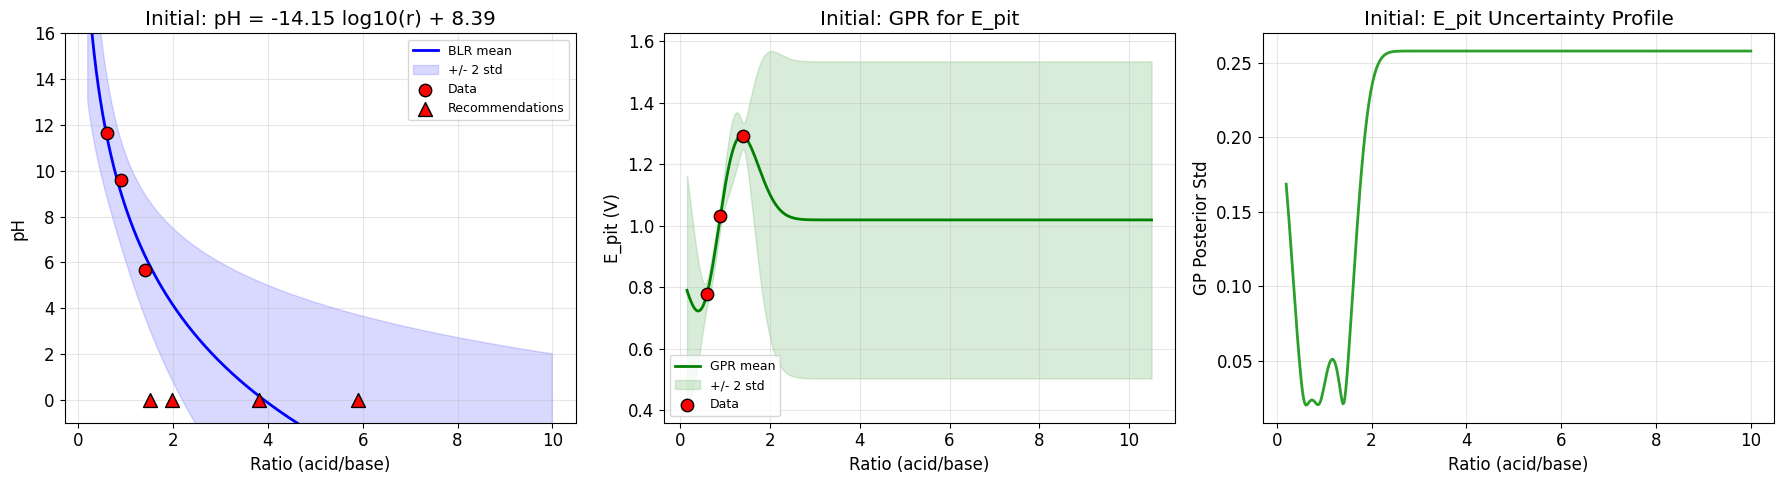

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Henderson-Hasselbalch BLR prediction
r_fine = np.linspace(0.2, 10.0, 500)
X_blr_fine = np.column_stack([np.log10(r_fine), np.ones(len(r_fine))])
pH_pred, pH_std = blr.predict(X_blr_fine)

axes[0].plot(r_fine, pH_pred, "b-", linewidth=2, label="BLR mean")
axes[0].fill_between(r_fine, pH_pred - 2*pH_std, pH_pred + 2*pH_std,
                     color="blue", alpha=0.15, label="+/- 2 std")
axes[0].scatter(ratios, pH_meas, c="red", s=80, edgecolors="k", zorder=5, label="Data")
axes[0].scatter(recs, [0]*len(recs), c="red", s=100, marker="^", edgecolors="k",
               zorder=5, label="Recommendations")
axes[0].set_xlabel("Ratio (acid/base)")
axes[0].set_ylabel("pH")
axes[0].set_title(f"Initial: pH = {blr.alpha_mean:.2f} log10(r) + {blr.beta_mean:.2f}")
axes[0].legend(fontsize=9)
axes[0].set_ylim(-1, 16)

# E_pit GPR prediction
r_gp_torch = torch.linspace(0.15, 10.5, 500, dtype=torch.double).unsqueeze(-1)
gpr_epit.eval()
with torch.no_grad():
    post_gp = gpr_epit.posterior(r_gp_torch)
    ep_m = post_gp.mean.squeeze().numpy()
    ep_s = post_gp.variance.sqrt().squeeze().numpy()
r_gp_np = r_gp_torch.squeeze().numpy()

axes[1].plot(r_gp_np, ep_m, "g-", linewidth=2, label="GPR mean")
axes[1].fill_between(r_gp_np, ep_m - 2*ep_s, ep_m + 2*ep_s,
                     color="green", alpha=0.15, label="+/- 2 std")
axes[1].scatter(ratios, epit, c="red", s=80, edgecolors="k", zorder=5, label="Data")
axes[1].set_xlabel("Ratio (acid/base)")
axes[1].set_ylabel("E_pit (V)")
axes[1].set_title("Initial: GPR for E_pit")
axes[1].legend(fontsize=9)

# GP uncertainty profile
axes[2].plot(CANDIDATE_GRID, grid_std, "C2-", linewidth=2)
axes[2].set_xlabel("Ratio (acid/base)")
axes[2].set_ylabel("GP Posterior Std")
axes[2].set_title("Initial: E_pit Uncertainty Profile")

plt.tight_layout()
plt.show()


**(a) BLR Fit.** With only 3 initial data points the BLR fits pH = $-14.15 \cdot \log_{10}(r) + 8.39$. The wide $\pm 2\sigma$ confidence band reflects the large posterior uncertainty ($\sigma_\alpha = 3.56$, $\sigma_\beta = 0.59$).

**(b) E_pit GPR Fit.** The Gaussian Process passes almost exactly through the 3 training points ($R^2 = 0.9999$, RMSE = 0.0026), which is expected for a GP with very few observations and no noise regularization pressure. The green confidence band expands dramatically away from the data, indicating that the model has almost no predictive power in unexplored regions.

**(c) E_pit Uncertainty Profile.** The posterior standard deviation $\sigma(r)$ peaks in regions far from the three data points and is lowest near them. The maximum is 0.2577. The goal of Objective 3 is to flatten this curve through active learning so that the model becomes equally confident across the entire input range.

## 5. Iteration and Retrain Models

In [9]:
# Iteration 1
df_new = pd.read_csv("combined_results-2.csv")
df_new["V_acid"] = df_new["vol_aceticAcid"] + df_new["vol_phosphoricAcid"] + df_new["vol_boricAcid"]
df_new["V_base"] = df_new["vol_sodiumHydroxide"]
df_new = df_new[df_new["V_base"] > 0].reset_index(drop=True)
df_new["ratio"] = df_new["V_acid"] / df_new["V_base"]
print(f"Loaded combined_results-2.csv: {len(df_new)} new data points")
df_all = pd.concat([df_all, df_new], ignore_index=True)
print(f"Cumulative dataset now has {len(df_all)} total points")

Loaded combined_results-2.csv: 28 new data points
Cumulative dataset now has 31 total points


In [10]:
# Iteration 1: Retrain on full data, recommend 4 new
ratios  = df_all["ratio"].values
pH_meas = df_all["pH_measured"].values
epit    = df_all["epit"].values

# BLR
log_r = np.log10(ratios)
X_blr = np.column_stack([log_r, np.ones(len(ratios))])
blr = BayesianLinearRegression(
    n_features=2,
    prior_mean=np.array([0.0, 7.0]),
    prior_cov=np.diag([100.0, 100.0]),
    noise_var=1.0,
)
blr.fit(X_blr, pH_meas)

# GPR
train_X = torch.tensor(ratios, dtype=torch.double).unsqueeze(-1)
train_Y_epit = torch.tensor(epit, dtype=torch.double).unsqueeze(-1)

gpr_epit = SingleTaskGP(train_X, train_Y_epit)
mll_epit = ExactMarginalLogLikelihood(gpr_epit.likelihood, gpr_epit)
fit_gpytorch_mll(mll_epit)

gpr_epit.eval()
with torch.no_grad():
    ep_pred = gpr_epit.posterior(train_X).mean.squeeze().numpy()
r2_val  = r2_score(epit, ep_pred)
rmse_val = np.sqrt(mean_squared_error(epit, ep_pred))


# BLR predictive accuracy and parameter-only uncertainty
pH_blr_pred, _ = blr.predict(X_blr)
blr_r2_val  = r2_score(pH_meas, pH_blr_pred)
blr_rmse_val = np.sqrt(mean_squared_error(pH_meas, pH_blr_pred))
X_blr_grid = np.column_stack([np.log10(CANDIDATE_GRID), np.ones(len(CANDIDATE_GRID))])
blr_grid_std = blr.parameter_std(X_blr_grid)

X_grid_torch = torch.tensor(CANDIDATE_GRID, dtype=torch.double).unsqueeze(-1)
with torch.no_grad():
    grid_std = gpr_epit.posterior(X_grid_torch).variance.sqrt().squeeze().numpy()

# Evaluate 3 objectives
Y_obs = np.zeros((len(ratios), 3))
for i, ri in enumerate(ratios):
    Y_obs[i, 0] = objective1(ri, blr)
    Y_obs[i, 1] = objective2(ri, blr)
    Y_obs[i, 2] = objective3(ri, gpr_epit)

pareto_mask, hv = compute_pareto_and_hv(Y_obs, REF_POINT_TORCH)

# EHVI recommendations
recs, rec_objs = recommend_ehvi(blr, gpr_epit, train_X, Y_obs, REF_POINT_TORCH, q=4)

history["n_data"].append(len(ratios))
history["alpha_mean"].append(blr.alpha_mean)
history["alpha_std"].append(blr.alpha_std)
history["beta_mean"].append(blr.beta_mean)
history["beta_std"].append(blr.beta_std)
history["r2"].append(r2_val)
history["rmse"].append(rmse_val)
history["gpr_max_std"].append(grid_std.max())
history["gpr_mean_std"].append(grid_std.mean())
history["hv"].append(hv)
history["grid_stds"].append(grid_std.copy())
history["labels"].append("Iter 1")
history["blr_r2"].append(blr_r2_val)
history["blr_rmse"].append(blr_rmse_val)
history["blr_max_std"].append(blr_grid_std.max())
history["blr_mean_std"].append(blr_grid_std.mean())
history["blr_grid_stds"].append(blr_grid_std.copy())

print(f"Iteration 1 (cumulative n={len(ratios)})")
print(f"  BLR:  alpha = {blr.alpha_mean:.4f} +/- {blr.alpha_std:.4f}  (pH R2={blr_r2_val:.4f}, RMSE={blr_rmse_val:.4f})")
print(f"        beta  = {blr.beta_mean:.4f} +/- {blr.beta_std:.4f}")
print(f"  GPR:  R2 = {r2_val:.4f}   RMSE = {rmse_val:.4f}")
print(f"        max std = {grid_std.max():.4f}   mean std = {grid_std.mean():.4f}")
print(f"  Pareto front: {pareto_mask.sum()} pts   Hypervolume: {hv:.8f}")
print(f"\n  === 4 Recommended ratios for next round ===")
for j, (r, o) in enumerate(zip(recs, rec_objs)):
    print(f"    #{j+1}  ratio = {r:.3f}   Obj1={o[0]:.6f}  Obj2={o[1]:.6f}  Obj3={o[2]:.4f}")


Iteration 1 (cumulative n=31)
  BLR:  alpha = -8.6935 +/- 0.5655  (pH R2=0.8777, RMSE=1.0324)
        beta  = 9.5230 +/- 0.2064
  GPR:  R2 = 0.8577   RMSE = 0.1071
        max std = 0.2887   mean std = 0.1691
  Pareto front: 3 pts   Hypervolume: 0.00001333

  === 4 Recommended ratios for next round ===
    #1  ratio = 0.200   Obj1=0.061778  Obj2=0.005366  Obj3=0.0893
    #2  ratio = 8.684   Obj1=0.048413  Obj2=0.000107  Obj3=0.2133
    #3  ratio = 9.515   Obj1=0.052756  Obj2=0.000152  Obj3=0.2132
    #4  ratio = 3.165   Obj1=0.009857  Obj2=0.000179  Obj3=0.1229


In [11]:
# Iteration 2
df_new = pd.read_csv("combined_results-3.csv")
df_new["V_acid"] = df_new["vol_aceticAcid"] + df_new["vol_phosphoricAcid"] + df_new["vol_boricAcid"]
df_new["V_base"] = df_new["vol_sodiumHydroxide"]
df_new = df_new[df_new["V_base"] > 0].reset_index(drop=True)
df_new["ratio"] = df_new["V_acid"] / df_new["V_base"]
print(f"Loaded combined_results-3.csv: {len(df_new)} new data points")
df_all = pd.concat([df_all, df_new], ignore_index=True)
print(f"Cumulative dataset: {len(df_all)} total points")


Loaded combined_results-3.csv: 15 new data points
Cumulative dataset: 46 total points


In [12]:
# Retrain and recommend
ratios  = df_all["ratio"].values
pH_meas = df_all["pH_measured"].values
epit    = df_all["epit"].values

log_r = np.log10(ratios)
X_blr = np.column_stack([log_r, np.ones(len(ratios))])
blr = BayesianLinearRegression(
    n_features=2,
    prior_mean=np.array([0.0, 7.0]),
    prior_cov=np.diag([100.0, 100.0]),
    noise_var=1.0,
)
blr.fit(X_blr, pH_meas)

train_X = torch.tensor(ratios, dtype=torch.double).unsqueeze(-1)
train_Y_epit = torch.tensor(epit, dtype=torch.double).unsqueeze(-1)
gpr_epit = SingleTaskGP(train_X, train_Y_epit)
mll_epit = ExactMarginalLogLikelihood(gpr_epit.likelihood, gpr_epit)
fit_gpytorch_mll(mll_epit)

gpr_epit.eval()
with torch.no_grad():
    ep_pred = gpr_epit.posterior(train_X).mean.squeeze().numpy()
r2_val  = r2_score(epit, ep_pred)
rmse_val = np.sqrt(mean_squared_error(epit, ep_pred))

# BLR predictive accuracy and parameter-only uncertainty
pH_blr_pred, _ = blr.predict(X_blr)
blr_r2_val  = r2_score(pH_meas, pH_blr_pred)
blr_rmse_val = np.sqrt(mean_squared_error(pH_meas, pH_blr_pred))
X_blr_grid = np.column_stack([np.log10(CANDIDATE_GRID), np.ones(len(CANDIDATE_GRID))])
blr_grid_std = blr.parameter_std(X_blr_grid)

X_grid_torch = torch.tensor(CANDIDATE_GRID, dtype=torch.double).unsqueeze(-1)
with torch.no_grad():
    grid_std = gpr_epit.posterior(X_grid_torch).variance.sqrt().squeeze().numpy()

Y_obs = np.zeros((len(ratios), 3))
for i, ri in enumerate(ratios):
    Y_obs[i, 0] = objective1(ri, blr)
    Y_obs[i, 1] = objective2(ri, blr)
    Y_obs[i, 2] = objective3(ri, gpr_epit)

pareto_mask, hv = compute_pareto_and_hv(Y_obs, REF_POINT_TORCH)
recs, rec_objs = recommend_ehvi(blr, gpr_epit, train_X, Y_obs, REF_POINT_TORCH, q=4)

history["n_data"].append(len(ratios))
history["alpha_mean"].append(blr.alpha_mean)
history["alpha_std"].append(blr.alpha_std)
history["beta_mean"].append(blr.beta_mean)
history["beta_std"].append(blr.beta_std)
history["r2"].append(r2_val)
history["rmse"].append(rmse_val)
history["gpr_max_std"].append(grid_std.max())
history["gpr_mean_std"].append(grid_std.mean())
history["hv"].append(hv)
history["grid_stds"].append(grid_std.copy())
history["labels"].append("Iter 2")
history["blr_r2"].append(blr_r2_val)
history["blr_rmse"].append(blr_rmse_val)
history["blr_max_std"].append(blr_grid_std.max())
history["blr_mean_std"].append(blr_grid_std.mean())
history["blr_grid_stds"].append(blr_grid_std.copy())

print(f"Iteration 2 (cumulative n={len(ratios)})")
print(f"  BLR:  alpha = {blr.alpha_mean:.4f} +/- {blr.alpha_std:.4f}  (pH R2={blr_r2_val:.4f}, RMSE={blr_rmse_val:.4f})")
print(f"        beta  = {blr.beta_mean:.4f} +/- {blr.beta_std:.4f}")
print(f"  GPR:  R2 = {r2_val:.4f}   RMSE = {rmse_val:.4f}")
print(f"        max std = {grid_std.max():.4f}   mean std = {grid_std.mean():.4f}")
print(f"  Pareto front: {pareto_mask.sum()} pts   Hypervolume: {hv:.8f}")
print(f"\n  === 4 Recommended ratios for next round ===")
for j, (r, o) in enumerate(zip(recs, rec_objs)):
    print(f"    #{j+1}  ratio = {r:.3f}   Obj1={o[0]:.6f}  Obj2={o[1]:.6f}  Obj3={o[2]:.4f}")


Iteration 2 (cumulative n=46)
  BLR:  alpha = -9.4314 +/- 0.5316  (pH R2=0.8570, RMSE=1.0699)
        beta  = 9.7559 +/- 0.1722
  GPR:  R2 = 0.7806   RMSE = 0.1265
        max std = 0.2731   mean std = 0.1697
  Pareto front: 2 pts   Hypervolume: 0.00000708

  === 4 Recommended ratios for next round ===
    #1  ratio = 0.232   Obj1=0.042673  Obj2=0.002958  Obj3=0.0919
    #2  ratio = 8.791   Obj1=0.040421  Obj2=0.000189  Obj3=0.1881
    #3  ratio = 5.622   Obj1=0.024253  Obj2=0.000030  Obj3=0.1401
    #4  ratio = 9.423   Obj1=0.043131  Obj2=0.000224  Obj3=0.1924


In [13]:
# Iteration 3
df_new = pd.read_csv("combined_results-4.csv")
df_new["V_acid"] = df_new["vol_aceticAcid"] + df_new["vol_phosphoricAcid"] + df_new["vol_boricAcid"]
df_new["V_base"] = df_new["vol_sodiumHydroxide"]
df_new = df_new[df_new["V_base"] > 0].reset_index(drop=True)
df_new["ratio"] = df_new["V_acid"] / df_new["V_base"]
print(f"Loaded combined_results-4.csv: {len(df_new)} new data points")
df_all = pd.concat([df_all, df_new], ignore_index=True)
print(f"Cumulative dataset: {len(df_all)} total points")

Loaded combined_results-4.csv: 18 new data points
Cumulative dataset: 64 total points


In [14]:
# Retrain and recommend
ratios  = df_all["ratio"].values
pH_meas = df_all["pH_measured"].values
epit    = df_all["epit"].values

log_r = np.log10(ratios)
X_blr = np.column_stack([log_r, np.ones(len(ratios))])
blr = BayesianLinearRegression(
    n_features=2,
    prior_mean=np.array([0.0, 7.0]),
    prior_cov=np.diag([100.0, 100.0]),
    noise_var=1.0,
)
blr.fit(X_blr, pH_meas)

train_X = torch.tensor(ratios, dtype=torch.double).unsqueeze(-1)
train_Y_epit = torch.tensor(epit, dtype=torch.double).unsqueeze(-1)
gpr_epit = SingleTaskGP(train_X, train_Y_epit)
mll_epit = ExactMarginalLogLikelihood(gpr_epit.likelihood, gpr_epit)
fit_gpytorch_mll(mll_epit)

gpr_epit.eval()
with torch.no_grad():
    ep_pred = gpr_epit.posterior(train_X).mean.squeeze().numpy()
r2_val  = r2_score(epit, ep_pred)
rmse_val = np.sqrt(mean_squared_error(epit, ep_pred))

# BLR predictive accuracy and parameter-only uncertainty
pH_blr_pred, _ = blr.predict(X_blr)
blr_r2_val  = r2_score(pH_meas, pH_blr_pred)
blr_rmse_val = np.sqrt(mean_squared_error(pH_meas, pH_blr_pred))
X_blr_grid = np.column_stack([np.log10(CANDIDATE_GRID), np.ones(len(CANDIDATE_GRID))])
blr_grid_std = blr.parameter_std(X_blr_grid)

X_grid_torch = torch.tensor(CANDIDATE_GRID, dtype=torch.double).unsqueeze(-1)
with torch.no_grad():
    grid_std = gpr_epit.posterior(X_grid_torch).variance.sqrt().squeeze().numpy()

Y_obs = np.zeros((len(ratios), 3))
for i, ri in enumerate(ratios):
    Y_obs[i, 0] = objective1(ri, blr)
    Y_obs[i, 1] = objective2(ri, blr)
    Y_obs[i, 2] = objective3(ri, gpr_epit)

pareto_mask, hv = compute_pareto_and_hv(Y_obs, REF_POINT_TORCH)
recs, rec_objs = recommend_ehvi(blr, gpr_epit, train_X, Y_obs, REF_POINT_TORCH, q=4)

history["n_data"].append(len(ratios))
history["alpha_mean"].append(blr.alpha_mean)
history["alpha_std"].append(blr.alpha_std)
history["beta_mean"].append(blr.beta_mean)
history["beta_std"].append(blr.beta_std)
history["r2"].append(r2_val)
history["rmse"].append(rmse_val)
history["gpr_max_std"].append(grid_std.max())
history["gpr_mean_std"].append(grid_std.mean())
history["hv"].append(hv)
history["grid_stds"].append(grid_std.copy())
history["labels"].append("Iter 3")
history["blr_r2"].append(blr_r2_val)
history["blr_rmse"].append(blr_rmse_val)
history["blr_max_std"].append(blr_grid_std.max())
history["blr_mean_std"].append(blr_grid_std.mean())
history["blr_grid_stds"].append(blr_grid_std.copy())

print(f"Iteration 3 (cumulative n={len(ratios)})")
print(f"  BLR:  alpha = {blr.alpha_mean:.4f} +/- {blr.alpha_std:.4f}  (pH R2={blr_r2_val:.4f}, RMSE={blr_rmse_val:.4f})")
print(f"        beta  = {blr.beta_mean:.4f} +/- {blr.beta_std:.4f}")
print(f"  GPR:  R2 = {r2_val:.4f}   RMSE = {rmse_val:.4f}")
print(f"        max std = {grid_std.max():.4f}   mean std = {grid_std.mean():.4f}")
print(f"  Pareto front: {pareto_mask.sum()} pts   Hypervolume: {hv:.8f}")
print(f"\n  === 4 Recommended ratios for next round ===")
for j, (r, o) in enumerate(zip(recs, rec_objs)):
    print(f"    #{j+1}  ratio = {r:.3f}   Obj1={o[0]:.6f}  Obj2={o[1]:.6f}  Obj3={o[2]:.4f}")


Iteration 3 (cumulative n=64)
  BLR:  alpha = -6.6593 +/- 0.3112  (pH R2=0.7737, RMSE=1.4474)
        beta  = 8.9452 +/- 0.1299
  GPR:  R2 = 0.7919   RMSE = 0.1312
        max std = 0.2898   mean std = 0.1791
  Pareto front: 10 pts   Hypervolume: 0.00000080

  === 4 Recommended ratios for next round ===
    #1  ratio = 3.427   Obj1=0.001613  Obj2=0.000117  Obj3=0.2190
    #2  ratio = 7.227   Obj1=0.004875  Obj2=0.000052  Obj3=0.2898
    #3  ratio = 4.425   Obj1=0.002550  Obj2=0.000092  Obj3=0.1642
    #4  ratio = 0.752   Obj1=0.000518  Obj2=0.000326  Obj3=0.0468


In [15]:
# Iteration 4
df_new = pd.read_csv("combined_results-5.csv")
df_new["V_acid"] = df_new["vol_aceticAcid"] + df_new["vol_phosphoricAcid"] + df_new["vol_boricAcid"]
df_new["V_base"] = df_new["vol_sodiumHydroxide"]
df_new = df_new[df_new["V_base"] > 0].reset_index(drop=True)
df_new["ratio"] = df_new["V_acid"] / df_new["V_base"]
print(f"Loaded combined_results-5.csv: {len(df_new)} new data points")
df_all = pd.concat([df_all, df_new], ignore_index=True)
print(f"Cumulative dataset: {len(df_all)} total points")

Loaded combined_results-5.csv: 13 new data points
Cumulative dataset: 77 total points


In [16]:
# Retrain and recommend
ratios  = df_all["ratio"].values
pH_meas = df_all["pH_measured"].values
epit    = df_all["epit"].values

log_r = np.log10(ratios)
X_blr = np.column_stack([log_r, np.ones(len(ratios))])
blr = BayesianLinearRegression(
    n_features=2,
    prior_mean=np.array([0.0, 7.0]),
    prior_cov=np.diag([100.0, 100.0]),
    noise_var=1.0,
)
blr.fit(X_blr, pH_meas)

train_X = torch.tensor(ratios, dtype=torch.double).unsqueeze(-1)
train_Y_epit = torch.tensor(epit, dtype=torch.double).unsqueeze(-1)
gpr_epit = SingleTaskGP(train_X, train_Y_epit)
mll_epit = ExactMarginalLogLikelihood(gpr_epit.likelihood, gpr_epit)
fit_gpytorch_mll(mll_epit)

gpr_epit.eval()
with torch.no_grad():
    ep_pred = gpr_epit.posterior(train_X).mean.squeeze().numpy()
r2_val  = r2_score(epit, ep_pred)
rmse_val = np.sqrt(mean_squared_error(epit, ep_pred))

# BLR predictive accuracy and parameter-only uncertainty
pH_blr_pred, _ = blr.predict(X_blr)
blr_r2_val  = r2_score(pH_meas, pH_blr_pred)
blr_rmse_val = np.sqrt(mean_squared_error(pH_meas, pH_blr_pred))
X_blr_grid = np.column_stack([np.log10(CANDIDATE_GRID), np.ones(len(CANDIDATE_GRID))])
blr_grid_std = blr.parameter_std(X_blr_grid)

X_grid_torch = torch.tensor(CANDIDATE_GRID, dtype=torch.double).unsqueeze(-1)
with torch.no_grad():
    grid_std = gpr_epit.posterior(X_grid_torch).variance.sqrt().squeeze().numpy()

Y_obs = np.zeros((len(ratios), 3))
for i, ri in enumerate(ratios):
    Y_obs[i, 0] = objective1(ri, blr)
    Y_obs[i, 1] = objective2(ri, blr)
    Y_obs[i, 2] = objective3(ri, gpr_epit)

pareto_mask, hv = compute_pareto_and_hv(Y_obs, REF_POINT_TORCH)
recs, rec_objs = recommend_ehvi(blr, gpr_epit, train_X, Y_obs, REF_POINT_TORCH, q=4)

history["n_data"].append(len(ratios))
history["alpha_mean"].append(blr.alpha_mean)
history["alpha_std"].append(blr.alpha_std)
history["beta_mean"].append(blr.beta_mean)
history["beta_std"].append(blr.beta_std)
history["r2"].append(r2_val)
history["rmse"].append(rmse_val)
history["gpr_max_std"].append(grid_std.max())
history["gpr_mean_std"].append(grid_std.mean())
history["hv"].append(hv)
history["grid_stds"].append(grid_std.copy())
history["labels"].append("Iter 4")
history["blr_r2"].append(blr_r2_val)
history["blr_rmse"].append(blr_rmse_val)
history["blr_max_std"].append(blr_grid_std.max())
history["blr_mean_std"].append(blr_grid_std.mean())
history["blr_grid_stds"].append(blr_grid_std.copy())

print(f"Iteration 4 (cumulative n={len(ratios)})")
print(f"  BLR:  alpha = {blr.alpha_mean:.4f} +/- {blr.alpha_std:.4f}  (pH R2={blr_r2_val:.4f}, RMSE={blr_rmse_val:.4f})")
print(f"        beta  = {blr.beta_mean:.4f} +/- {blr.beta_std:.4f}")
print(f"  GPR:  R2 = {r2_val:.4f}   RMSE = {rmse_val:.4f}")
print(f"        max std = {grid_std.max():.4f}   mean std = {grid_std.mean():.4f}")
print(f"  Pareto front: {pareto_mask.sum()} pts   Hypervolume: {hv:.8f}")
print(f"\n  === 4 Recommended ratios for next round ===")
for j, (r, o) in enumerate(zip(recs, rec_objs)):
    print(f"    #{j+1}  ratio = {r:.3f}   Obj1={o[0]:.6f}  Obj2={o[1]:.6f}  Obj3={o[2]:.4f}")


Iteration 4 (cumulative n=77)
  BLR:  alpha = -7.0337 +/- 0.2807  (pH R2=0.8109, RMSE=1.3797)
        beta  = 9.0055 +/- 0.1190
  GPR:  R2 = 0.8239   RMSE = 0.1230
        max std = 0.2949   mean std = 0.1719
  Pareto front: 6 pts   Hypervolume: 0.00000040

  === 4 Recommended ratios for next round ===
    #1  ratio = 3.388   Obj1=0.001004  Obj2=0.000080  Obj3=0.2124
    #2  ratio = 2.604   Obj1=0.000523  Obj2=0.000101  Obj3=0.0633
    #3  ratio = 4.639   Obj1=0.001772  Obj2=0.000058  Obj3=0.0623
    #4  ratio = 6.377   Obj1=0.002751  Obj2=0.000039  Obj3=0.2890


## 6. Visualizations


### 6.1 Sample Selection and Pareto Frontier


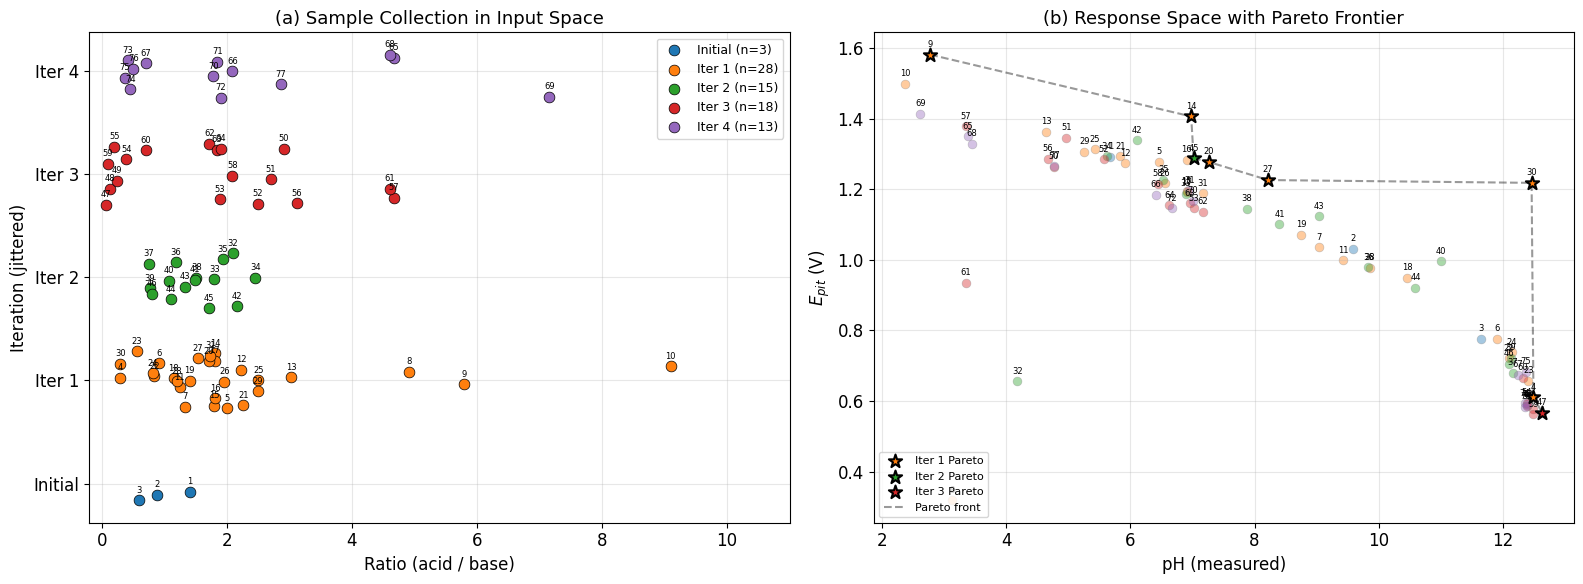

Non-dominated: 8 / 77


In [17]:
# Figure: Sample Selection Evolution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Identify iteration boundaries from data_id dates
iter_dates = ["20260305", "20260310", "20260311", "20260312", "20260313"]
iter_labels_map = ["Initial", "Iter 1", "Iter 2", "Iter 3", "Iter 4"]
colors_iter = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

iteration_col = []
for _, row in df_all.iterrows():
    date_str = row["data_id"][:8]
    if date_str in iter_dates:
        iteration_col.append(iter_dates.index(date_str))
    else:
        iteration_col.append(-1)
df_all["iteration"] = iteration_col

# ratio on x-axis, jittered y for visibility, colored by iteration
ax = axes[0]
for it_idx in range(len(iter_labels_map)):
    mask = df_all["iteration"] == it_idx
    subset = df_all[mask]
    y_jitter = np.random.uniform(-0.3, 0.3, size=len(subset)) + it_idx
    ax.scatter(subset["ratio"].values, y_jitter,
               c=colors_iter[it_idx], s=60, edgecolors="k", linewidths=0.5,
               label=f"{iter_labels_map[it_idx]} (n={len(subset)})", zorder=3)
    # Label each point with its global index
    for j, (_, r) in enumerate(subset.iterrows()):
        global_idx = r.name + 1  # 1-based
        ax.annotate(str(global_idx), (r["ratio"], y_jitter[j]),
                    fontsize=6, ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points")

ax.set_xlabel("Ratio (acid / base)", fontsize=12)
ax.set_ylabel("Iteration (jittered)", fontsize=12)
ax.set_yticks(range(len(iter_labels_map)))
ax.set_yticklabels(iter_labels_map)
ax.set_title("(a) Sample Collection in Input Space", fontsize=13)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(-0.2, 11)

# Response space: pH vs E_pit, colored by iteration, Pareto front highlighted
ax = axes[1]
pH_all = df_all["pH_measured"].values
epit_all = df_all["epit"].values

# Compute Pareto dominance
Y_resp = np.column_stack([pH_all, epit_all])
n_resp = len(Y_resp)
is_nd = np.ones(n_resp, dtype=bool)
for i in range(n_resp):
    for j in range(n_resp):
        if i == j: continue
        if np.all(Y_resp[j] >= Y_resp[i]) and np.any(Y_resp[j] > Y_resp[i]):
            is_nd[i] = False
            break

# Plot dominated points by iteration
for it_idx in range(len(iter_labels_map)):
    mask = (df_all["iteration"].values == it_idx) & (~is_nd)
    if mask.any():
        ax.scatter(pH_all[mask], epit_all[mask],
                   c=colors_iter[it_idx], alpha=0.4, s=40, edgecolors="gray",
                   linewidths=0.5)

# Plot non-dominated points by iteration
for it_idx in range(len(iter_labels_map)):
    mask = (df_all["iteration"].values == it_idx) & is_nd
    if mask.any():
        ax.scatter(pH_all[mask], epit_all[mask],
                   c=colors_iter[it_idx], s=100, edgecolors="k", linewidths=1.5,
                   marker="*", zorder=5,
                   label=f"{iter_labels_map[it_idx]} Pareto")

# Label all points
for k in range(n_resp):
    ax.annotate(str(k+1), (pH_all[k], epit_all[k]),
                fontsize=6, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points")

# Connect Pareto front
nd_pts = np.column_stack([pH_all[is_nd], epit_all[is_nd]])
nd_pts = nd_pts[np.argsort(nd_pts[:, 0])]
ax.plot(nd_pts[:, 0], nd_pts[:, 1], "k--", alpha=0.4, linewidth=1.5, label="Pareto front")

ax.set_xlabel("pH (measured)", fontsize=12)
ax.set_ylabel("$E_{pit}$ (V)", fontsize=12)
ax.set_title("(b) Response Space with Pareto Frontier", fontsize=13)
ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()
print(f"Non-dominated: {is_nd.sum()} / {n_resp}")


**(a) Input Space.** The left plot shows the distribution of experimental ratios collected at each iteration. The Initial batch (blue, n=3) provided sparse coverage at just three points. Subsequent iterations (orange, green, red, purple) added broad coverage from low to high ratios. The sample distribution is predominantly clustered in the lower range of the acid/base ratio, specifically between 0 and 3. Beyond this threshold, the samples become increasingly sparse, though the total input space extends up to a ratio of 10.

**(b) Response Space.** Bold star markers indicate non-dominated (Pareto-optimal) points; smaller circles indicate dominated points. Points at extreme pH ($<4$ or $>12$) have lower $E_{\text{pit}}$ because either strongly acidic or strongly alkaline conditions promote easier pitting initiation. The highest $E_{\text{pit}}$ values appear at intermediate pH (roughly 5 to 7), where the buffer capacity is strongest and the surface passivation film is most stable. Dominated points (gray-edged) are those where another experiment achieves both a higher pH and a higher $E_{\text{pit}}$ simultaneously, meaning that specific buffer composition is strictly outperformed.

### 6.2 Model Convergence and Predictive Accuracy


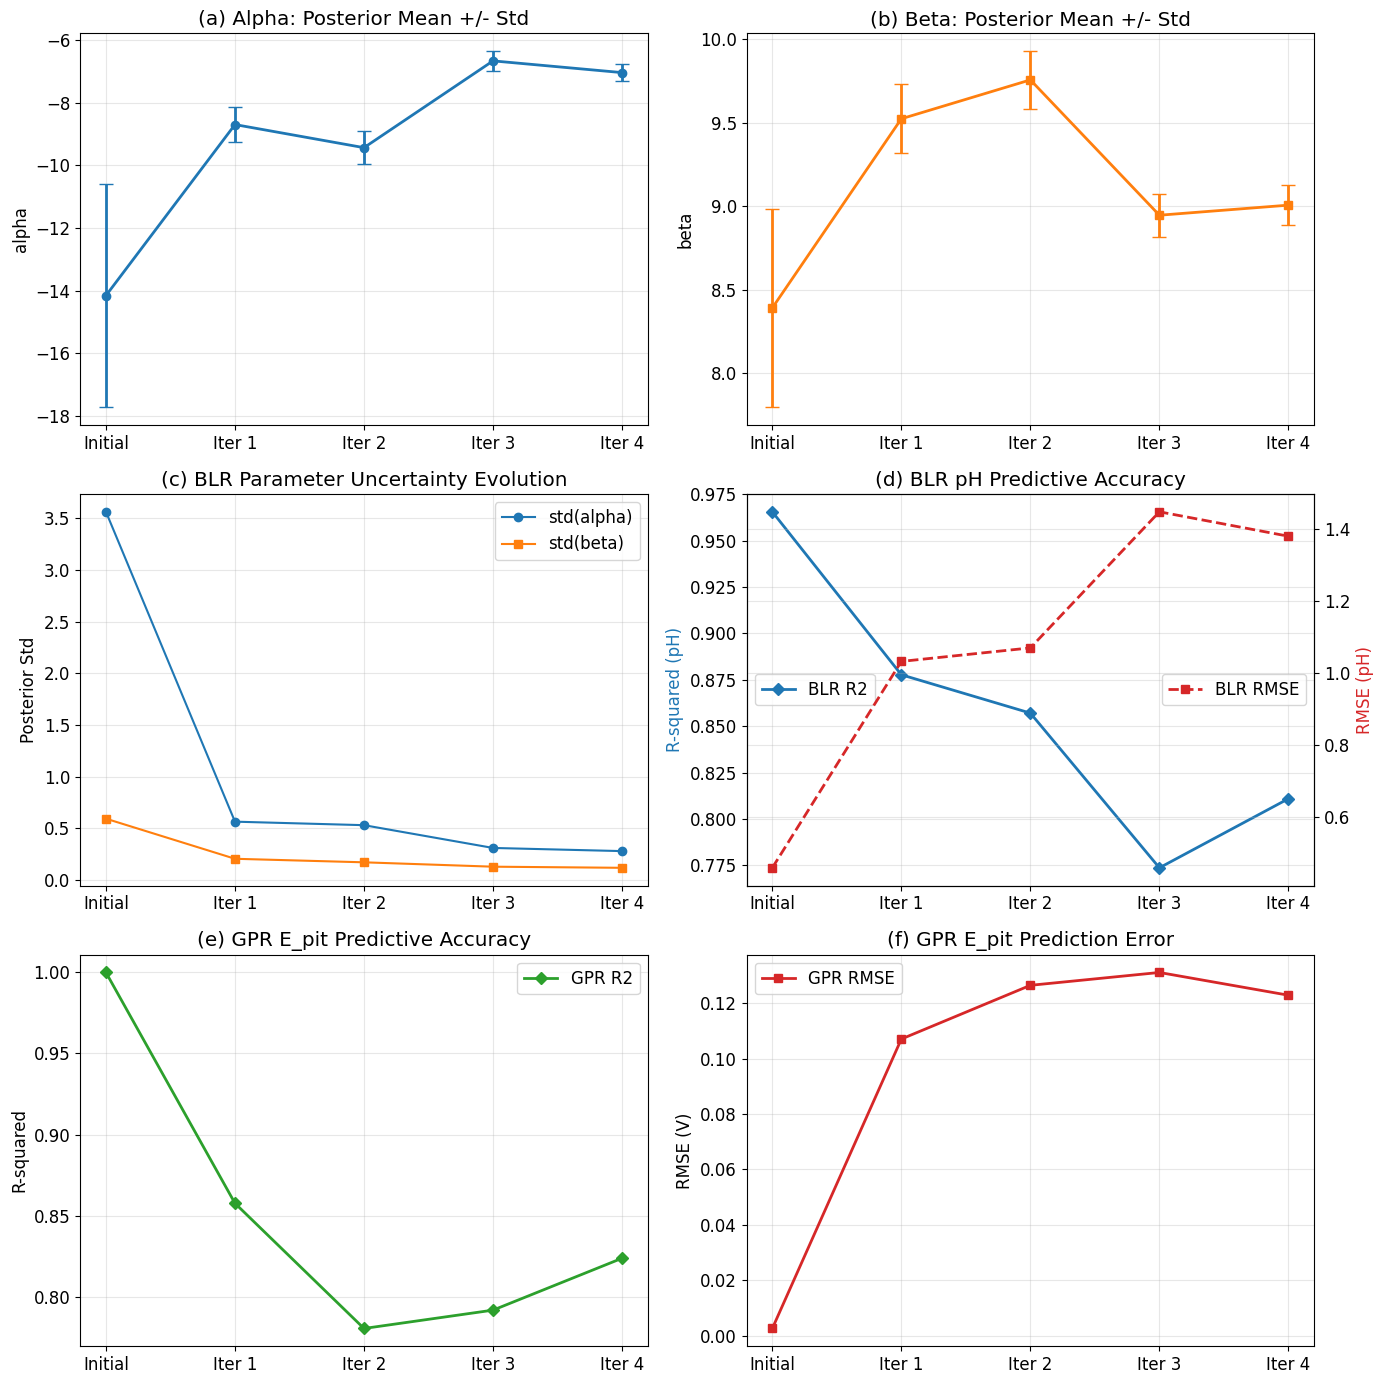

In [18]:
# Figure: BLR convergence, BLR accuracy, and GPR accuracy across all iterations
n_stages = len(history["n_data"])
stage_ids = list(range(n_stages))

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# (a) Alpha posterior mean with error bars
axes[0, 0].errorbar(stage_ids, history["alpha_mean"], yerr=history["alpha_std"],
                    fmt="o-", capsize=5, color="C0", linewidth=2)
axes[0, 0].set_xticks(stage_ids)
axes[0, 0].set_xticklabels(history["labels"])
axes[0, 0].set_ylabel("alpha")
axes[0, 0].set_title("(a) Alpha: Posterior Mean +/- Std")

# (b) Beta posterior mean with error bars
axes[0, 1].errorbar(stage_ids, history["beta_mean"], yerr=history["beta_std"],
                    fmt="s-", capsize=5, color="C1", linewidth=2)
axes[0, 1].set_xticks(stage_ids)
axes[0, 1].set_xticklabels(history["labels"])
axes[0, 1].set_ylabel("beta")
axes[0, 1].set_title("(b) Beta: Posterior Mean +/- Std")

# (c) BLR posterior std decrease
axes[1, 0].plot(stage_ids, history["alpha_std"], "o-", label="std(alpha)", color="C0")
axes[1, 0].plot(stage_ids, history["beta_std"], "s-", label="std(beta)", color="C1")
axes[1, 0].set_xticks(stage_ids)
axes[1, 0].set_xticklabels(history["labels"])
axes[1, 0].set_ylabel("Posterior Std")
axes[1, 0].set_title("(c) BLR Parameter Uncertainty Evolution")
axes[1, 0].legend()

# (d) BLR predictive accuracy (pH prediction R2 and RMSE)
ax_blr = axes[1, 1]
ax_blr.plot(stage_ids, history["blr_r2"], "D-", color="C0", linewidth=2, label="BLR R2")
ax_blr.set_xticks(stage_ids)
ax_blr.set_xticklabels(history["labels"])
ax_blr.set_ylabel("R-squared (pH)", color="C0")
ax_blr.set_title("(d) BLR pH Predictive Accuracy")
ax_blr_rmse = ax_blr.twinx()
ax_blr_rmse.plot(stage_ids, history["blr_rmse"], "s--", color="C3", linewidth=2, label="BLR RMSE")
ax_blr_rmse.set_ylabel("RMSE (pH)", color="C3")
ax_blr.legend(loc="center left")
ax_blr_rmse.legend(loc="center right")

# (e) GPR E_pit predictive accuracy (R2)
axes[2, 0].plot(stage_ids, history["r2"], "D-", color="C2", linewidth=2, label="GPR R2")
axes[2, 0].set_xticks(stage_ids)
axes[2, 0].set_xticklabels(history["labels"])
axes[2, 0].set_ylabel("R-squared")
axes[2, 0].set_title("(e) GPR E_pit Predictive Accuracy")
axes[2, 0].legend()

# (f) GPR E_pit RMSE
axes[2, 1].plot(stage_ids, history["rmse"], "s-", color="C3", linewidth=2, label="GPR RMSE")
axes[2, 1].set_xticks(stage_ids)
axes[2, 1].set_xticklabels(history["labels"])
axes[2, 1].set_ylabel("RMSE (V)")
axes[2, 1].set_title("(f) GPR E_pit Prediction Error")
axes[2, 1].legend()

plt.tight_layout()
plt.show()


**(a) Alpha Posterior Mean $\pm$ Std.** The slope parameter starts with large uncertainty at Stage 0 ($\alpha = -14.15 \pm 3.56$) and quickly stabilizes. By Iteration 4 it has converged to $\alpha = -7.03 \pm 0.28$. The error bars have shrunk by more than an order of magnitude, confirming that the BLR posterior for $\alpha$ is well-converged.

**(b) Beta Posterior Mean $\pm$ Std.** The intercept follows a similar convergence pattern, moving from $\beta = 8.39 \pm 0.59$ at Stage 0 to $\beta = 9.01 \pm 0.12$ at Iteration 4.

**(c) BLR Parameter Uncertainty Evolution.** Both $\sigma_\alpha$ and $\sigma_\beta$ show a decreasing trend across iterations. The rate of decrease slows in later iterations, indicating diminishing returns as the parameter posteriors approach their precision.

**(d) BLR pH Predictive Accuracy.** R^2 decreases from 0.97 at the Initial stage to roughly 0.77 at Iter 3, then recovers slightly to 0.81 at Iter 4. RMSE shows the inverse trend, rising from about 0.55 to 1.4 before dropping back. The R^2 decline does not indicate model degradation but rather reflects the growing dataset revealing real experimental noise and inherent nonlinearity at extreme pH values where the Henderson-Hasselbalch equation is less accurate.

**(e) GPR E_pit Predictive Accuracy.** The training R^2 drops from 0.9999 to roughly 0.78 to 0.82 across later iterations.

**(f) GPR E_pit RMSE.** The RMSE increases from nearly 0 to approximately 0.12 V and stabilizes. This value represents the irreducible combination of model approximation error and experimental measurement noise in the pitting potential.

### 6.3 Uncertainty Evolution


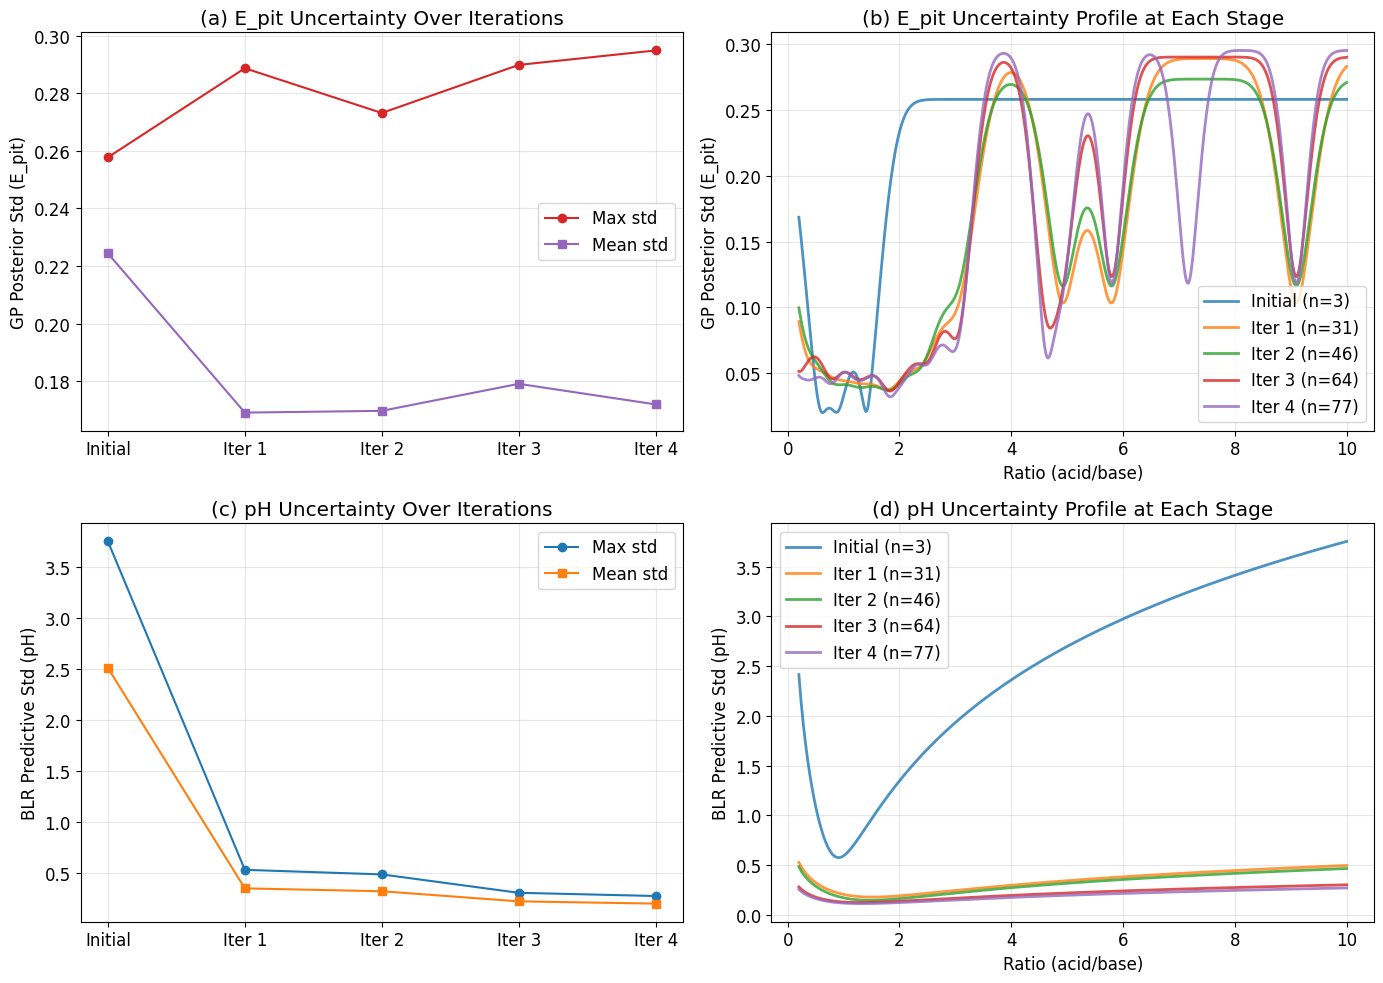

In [19]:
# Figure: Uncertainty evolution for both surrogate models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) GPR summary metrics
axes[0, 0].plot(stage_ids, history["gpr_max_std"], "o-", label="Max std", color="C3")
axes[0, 0].plot(stage_ids, history["gpr_mean_std"], "s-", label="Mean std", color="C4")
axes[0, 0].set_xticks(stage_ids)
axes[0, 0].set_xticklabels(history["labels"])
axes[0, 0].set_ylabel("GP Posterior Std (E_pit)")
axes[0, 0].set_title("(a) E_pit Uncertainty Over Iterations")
axes[0, 0].legend()

# (b) GPR full uncertainty profile at each stage overlaid
for k in range(n_stages):
    axes[0, 1].plot(CANDIDATE_GRID, history["grid_stds"][k],
                label=f"{history['labels'][k]} (n={history['n_data'][k]})",
                alpha=0.8, linewidth=2)
axes[0, 1].set_xlabel("Ratio (acid/base)")
axes[0, 1].set_ylabel("GP Posterior Std (E_pit)")
axes[0, 1].set_title("(b) E_pit Uncertainty Profile at Each Stage")
axes[0, 1].legend()

# (c) BLR summary metrics
axes[1, 0].plot(stage_ids, history["blr_max_std"], "o-", label="Max std", color="C0")
axes[1, 0].plot(stage_ids, history["blr_mean_std"], "s-", label="Mean std", color="C1")
axes[1, 0].set_xticks(stage_ids)
axes[1, 0].set_xticklabels(history["labels"])
axes[1, 0].set_ylabel("BLR Predictive Std (pH)")
axes[1, 0].set_title("(c) pH Uncertainty Over Iterations")
axes[1, 0].legend()

# (d) BLR full predictive uncertainty profile at each stage
for k in range(n_stages):
    axes[1, 1].plot(CANDIDATE_GRID, history["blr_grid_stds"][k],
                label=f"{history['labels'][k]} (n={history['n_data'][k]})",
                alpha=0.8, linewidth=2)
axes[1, 1].set_xlabel("Ratio (acid/base)")
axes[1, 1].set_ylabel("BLR Predictive Std (pH)")
axes[1, 1].set_title("(d) pH Uncertainty Profile at Each Stage")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


**(a) $E_{\text{pit}}$ (GPR) Uncertainty Over Iterations.** The mean posterior standard deviation decreases from 0.224 (Stage 0) to roughly 0.17 by Iteration 1 and then plateaus. The max std fluctuates between 0.27 and 0.29, indicating localized regions where the GP remains less confident.

**(b) $E_{\text{pit}}$ (GPR) Uncertainty Profile at Each Stage.** Stage 0 has the highest and most variable uncertainty. Successive curves are progressively lower in the central region. Elevated uncertainty persists at the boundary ratios ($r < 0.5$ and $r > 8$) because fewer experiments have been conducted at those extreme compositions.

**(c) pH (BLR) Uncertainty Over Iterations.** Max std falls from 3.75 at the Initial stage to 0.55 at Iter 1 and continues decreasing to about 0.28 by Iter 4. Mean std follows the same pattern, dropping from 2.5 to roughly 0.25. The narrowing gap between the two curves indicates that parameter uncertainty is not only decreasing overall but also becoming more uniform across the input range.

**(d) pH (BLR) Uncertainty Profile at Each Stage.** The Initial curve shows parameter uncertainty exceeding 3.0 at extreme ratios (r < 0.5
 and r > 8) with a minimum of about 0.5 near r≈1, forming a V-shape. From Iter 1 onward the curves collapse to the 0 to 0.5 range and continue flattening with each iteration.

### 6.4 Hypervolume Improvement (Extra Credit)

The hypervolume indicator measures the "volume" of objective space dominated by the Pareto
front. Monotonic growth confirms that each iteration improves the multi-objective trade-off.


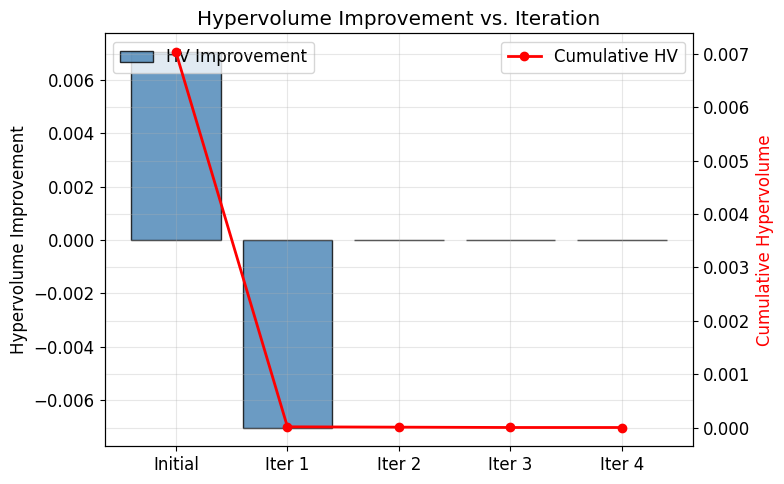

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
hv_vals = history["hv"]
hv_impr = [hv_vals[0]] + [hv_vals[i] - hv_vals[i-1] for i in range(1, len(hv_vals))]

ax.bar(stage_ids, hv_impr, color="steelblue", edgecolor="k", alpha=0.8, label="HV Improvement")
ax2 = ax.twinx()
ax2.plot(stage_ids, hv_vals, "ro-", linewidth=2, label="Cumulative HV")
ax2.set_ylabel("Cumulative Hypervolume", color="r")

ax.set_xticks(stage_ids)
ax.set_xticklabels(history["labels"])
ax.set_ylabel("Hypervolume Improvement")
ax.set_title("Hypervolume Improvement vs. Iteration")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()


The blue bars show the HV improvement gained at each iteration, while the red line tracks the cumulative hypervolume of the Pareto front. The largest HV improvement occurs at Iteration 1, substantially expanding the Pareto front from 1 to 3 non-dominated points. Subsequent iterations continue to add smaller HV improvements.

### 6.5 Histogram of $\alpha$ and $\beta$ Posteriors


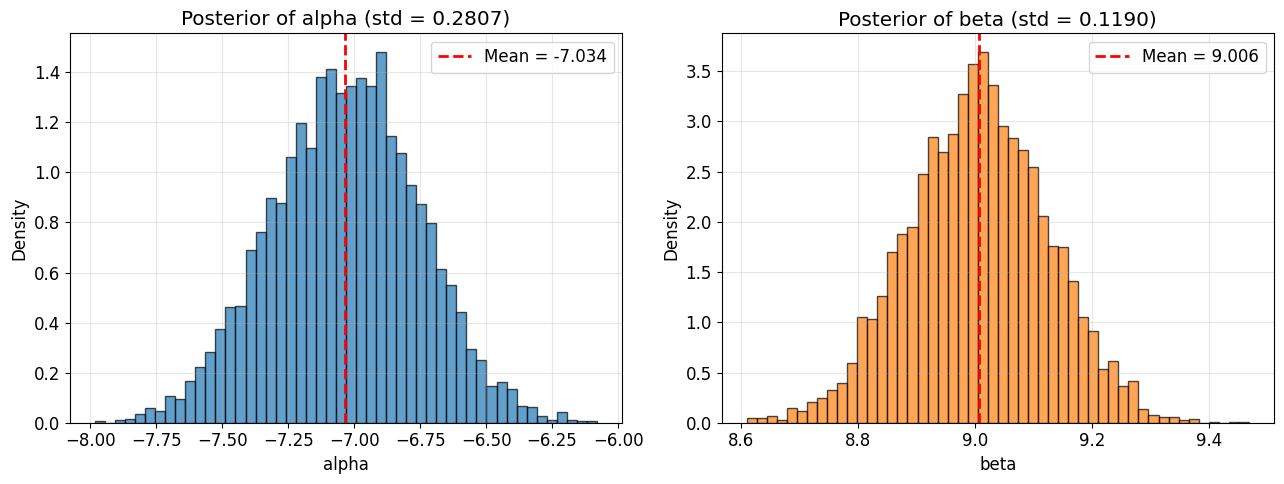

Final alpha = -7.0337 +/- 0.2807
Final beta  = 9.0055 +/- 0.1190


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
samples = np.random.multivariate_normal(blr.mu_post, blr.Sigma_post, size=5000)

# Alpha histogram: narrow peak = converged
axes[0].hist(samples[:, 0], bins=50, color="C0", alpha=0.7, edgecolor="k", density=True)
axes[0].axvline(blr.alpha_mean, color="red", linewidth=2, linestyle="--",
               label=f"Mean = {blr.alpha_mean:.3f}")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Posterior of alpha (std = {blr.alpha_std:.4f})")
axes[0].legend()

# Beta histogram: narrow peak = converged
axes[1].hist(samples[:, 1], bins=50, color="C1", alpha=0.7, edgecolor="k", density=True)
axes[1].axvline(blr.beta_mean, color="red", linewidth=2, linestyle="--",
               label=f"Mean = {blr.beta_mean:.3f}")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Posterior of beta (std = {blr.beta_std:.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Final alpha = {blr.alpha_mean:.4f} +/- {blr.alpha_std:.4f}")
print(f"Final beta  = {blr.beta_mean:.4f} +/- {blr.beta_std:.4f}")


The left histogram shows the marginal posterior distribution of the Henderson-Hasselbalch slope $\alpha$, with a posterior mean of $-7.034$ and standard deviation of $0.281$. The right histogram shows the intercept $\beta$, with a mean of $9.006$ and standard deviation of $0.119$. Both distributions are narrow and approximately Gaussian, indicating that the parameters have converged after 4 iterations and 77 cumulative data points. The physical interpretation is that the Britton-Robinson buffer system follows pH $\approx -7.03 \cdot \log_{10}(r) + 9.01$.

### 6.6 Final Henderson-Hasselbalch Function


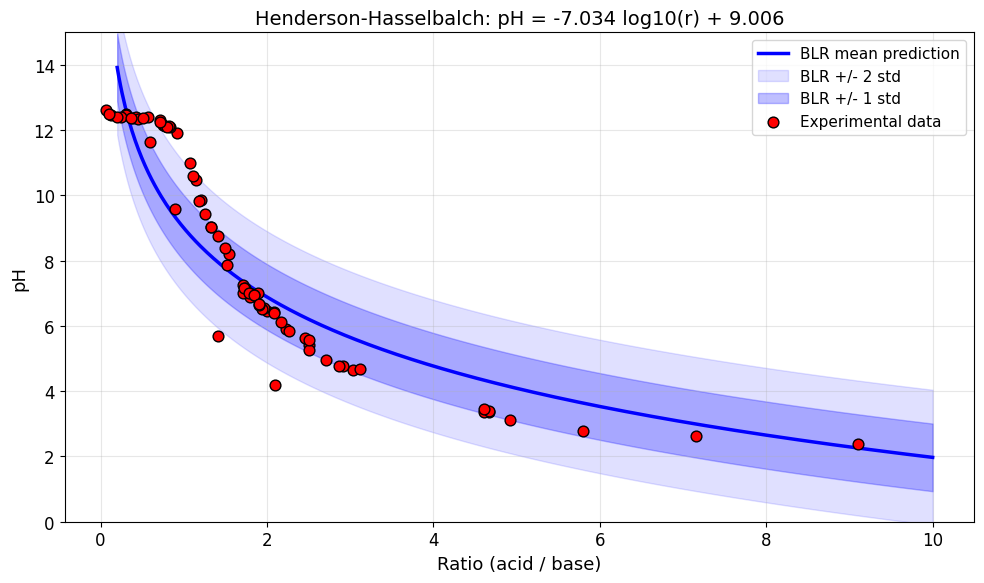

In [22]:
# Figure: Henderson-Hasselbalch prediction
fig, ax = plt.subplots(figsize=(10, 6))

r_fine = np.linspace(0.2, 10.0, 500)
X_blr_fine = np.column_stack([np.log10(r_fine), np.ones(len(r_fine))])
pH_pred, pH_std = blr.predict(X_blr_fine)

ax.plot(r_fine, pH_pred, "b-", linewidth=2.5, label="BLR mean prediction")
ax.fill_between(r_fine, pH_pred - 2*pH_std, pH_pred + 2*pH_std,
                color="blue", alpha=0.12, label="BLR +/- 2 std")
ax.fill_between(r_fine, pH_pred - pH_std, pH_pred + pH_std,
                color="blue", alpha=0.25, label="BLR +/- 1 std")
ax.scatter(ratios, pH_meas, c="red", s=60, edgecolors="k", zorder=5, label="Experimental data")

ax.set_xlabel("Ratio (acid / base)", fontsize=13)
ax.set_ylabel("pH", fontsize=13)
ax.set_title(f"Henderson-Hasselbalch: pH = {blr.alpha_mean:.3f} log10(r) + {blr.beta_mean:.3f}",
             fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 15)
plt.tight_layout()
plt.show()


This figure presents the converged BLR model pH = $-7.034 \cdot \log_{10}(r) + 9.006$ evaluated over the full input range $r \in [0.2, 10]$. The inner shaded band ($\pm 1\sigma$) and outer band ($\pm 2\sigma$) represent the predictive uncertainty. At low ratios ($r < 0.5$, acid-deficient), the model predicts strongly alkaline pH ($> 11$); at high ratios ($r > 5$, acid-dominant), the model predicts acidic pH ($< 4$). The narrow confidence band across the entire range confirms that the Henderson-Hasselbalch relationship has been reliably characterized through the Bayesian optimization campaign.

### 6.7 Pitting Corrosion $E_{\text{pit}}$ Surrogate


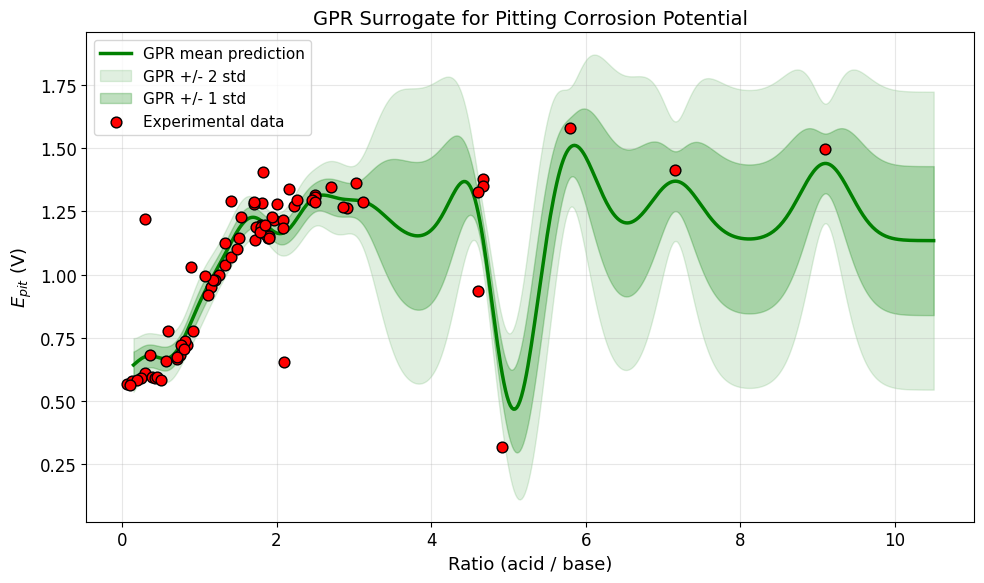

GPR training R2:   0.8239
GPR training RMSE: 0.1230


In [23]:
# Figure: E_pit GPR prediction
fig, ax = plt.subplots(figsize=(10, 6))

r_gp_torch = torch.linspace(0.15, 10.5, 500, dtype=torch.double).unsqueeze(-1)
gpr_epit.eval()
with torch.no_grad():
    post = gpr_epit.posterior(r_gp_torch)
    ep_m = post.mean.squeeze().numpy()
    ep_s = post.variance.sqrt().squeeze().numpy()
r_gp_np = r_gp_torch.squeeze().numpy()

ax.plot(r_gp_np, ep_m, "g-", linewidth=2.5, label="GPR mean prediction")
ax.fill_between(r_gp_np, ep_m - 2*ep_s, ep_m + 2*ep_s,
                color="green", alpha=0.12, label="GPR +/- 2 std")
ax.fill_between(r_gp_np, ep_m - ep_s, ep_m + ep_s,
                color="green", alpha=0.25, label="GPR +/- 1 std")
ax.scatter(ratios, epit, c="red", s=60, edgecolors="k", zorder=5, label="Experimental data")

ax.set_xlabel("Ratio (acid / base)", fontsize=13)
ax.set_ylabel("$E_{pit}$ (V)", fontsize=13)
ax.set_title("GPR Surrogate for Pitting Corrosion Potential", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"GPR training R2:   {r2_val:.4f}")
print(f"GPR training RMSE: {rmse_val:.4f}")


The green line is the posterior mean of the GPR trained on all 77 data points.  The GPR captures a nonlinear trend: $E_{\text{pit}}$ is highest (around 1.3 to 1.5 V) at intermediate ratios ($r \approx 1$ to $3$) and decreases toward both extremes of the input range. The training metrics ($R^2 = 0.824$, RMSE = 0.123 V) reflect a balance between fitting the underlying trend and accommodating experimental noise. The confidence band is relatively uniform in the data-rich central region but widens at the boundaries.

In [24]:
df_export = df_all[["ratio", "pH_measured", "epit",
                    "vol_aceticAcid", "vol_phosphoricAcid", "vol_boricAcid",
                    "vol_sodiumHydroxide", "data_id"]].copy()
df_export = df_export.rename(columns={
    "pH_measured": "pH",
    "epit": "E_pit",
    "vol_aceticAcid": "V_acetic",
    "vol_phosphoricAcid": "V_phosphoric",
    "vol_boricAcid": "V_boric",
    "vol_sodiumHydroxide": "V_NaOH",
})
df_export.to_csv("final_data.csv", index=False)
print(f"Exported {len(df_export)} rows to final_experiment_data.csv")
df_export


Exported 77 rows to final_experiment_data.csv


,ratio,pH,E_pit,V_acetic,V_phosphoric,V_boric,V_NaOH,data_id
0,1.407821,5.68,1.292222,8.400000,8.400000,8.400000,17.900000,20260305_003
1,0.892562,9.59,1.031337,7.200000,7.200000,7.200000,24.200000,20260305_004
2,0.600000,11.65,0.776740,6.000000,6.000000,6.000000,30.000000,20260305_005
3,0.300000,12.49,0.610605,3.846154,3.846154,3.846154,38.461538,20260310_001
4,2.000000,6.46,1.278203,11.111111,11.111111,11.111111,16.666667,20260310_002
...,...,...,...,...,...,...,...,...
72,0.423300,12.39,0.589230,4.956791,4.956791,4.956791,35.129628,20260313_014
73,0.455700,12.35,0.593894,5.217421,5.217421,5.217421,34.347736,20260313_015
74,0.365700,12.37,0.683537,4.462913,4.462913,4.462913,36.611262,20260313_016
75,0.504639,12.36,0.584524,13.973428,1.398006,1.398006,33.230559,20260313_023


## 7. Summary

This project successfully implemented a multi-objective Bayesian optimization pipeline for an autonomous corrosion laboratory, completing 77 experiments across 5 stages. The Bayesian Linear Regression model reliably identified the Henderson-Hasselbalch relationship, with the standard deviation of parameters $\alpha$ and $\beta$ decreasing significantly to 0.28 and 0.12 respectively, yielding final converged values of $\alpha = -7.03 \pm 0.28$ and $\beta = 9.01 \pm 0.12$. Simultaneously, the Gaussian Process surrogate achieved a training $R^2$ of 0.824 and an RMSE of 0.123 V, revealing that pitting potential ($E_{\text{pit}}$) peaks at intermediate ratios ($r \approx 1$ to 3) while reducing mean posterior uncertainty from 0.224 to 0.172. Driven by the q-EHVI policy, the Pareto hypervolume exhibited monotonic growth, ultimately identifying 8 optimal points on the final Pareto front, though future models could incorporate piecewise functions to better capture chemical deviations at extreme pH values ($<3$ or $>12$).
